In [12]:
from matplotlib import pyplot as plt
# from brokenaxes import brokenaxes
import numpy as np
import os
import sys
import matplotlib.ticker as mticker
from matplotlib.ticker import FuncFormatter

my_figsize = [10, 8]
my_fontsize = 35
WIDTH = 0.05  # the width of the bars
SHORT = 100001 # 100KB
LONG = 1000000 # 1000KB
METRICS = ['GOODPUT', 'FCT']


os.chdir(sys.path[0])
os.chdir('./')

SCHEMES = [
        
        "../../DATA/Ideal/incast", 
        "../../DATA/1x/incast", 
        "../../DATA/2x/incast",
        "../../../DCTCP/DATA/thesis/incast",
        ]

# SCHEMES_labels = ["Ideal", "HeirSchedule", "HeirSchedule(2x)", "DCTCP"]
SCHEMES_labels = [
                "理想情况",
                "本方案",
                "本方案(2x)",
                "DCTCP",
                 ]
workloads = ["incast_20", "incast_40", "incast_60", "incast_80", "incast_100", "incast_120"]
incast_degree = [20, 40, 60, 80, 100, 120]

DATA_DIR_TEMP = '{scheme}/DATA_{workload}/'

data = {}
for scheme in SCHEMES:
    data[scheme] = {}
    for workload in workloads:
        data[scheme][workload] = {}
    
for scheme in SCHEMES:
    for workload in workloads:
        dir_path = DATA_DIR_TEMP.format(scheme=scheme, workload=workload)
        data[scheme][workload]['PATH'] = dir_path
        for metric in METRICS:
            data_path = dir_path + metric + '.txt'
            data[scheme][workload][metric] = np.loadtxt(data_path)

20
40
60
80
100
120
20
40
60
80
100
120
20
40
60
80
100
120
20
40
60
80
100
120
{'../../DATA/Ideal/incast': [0.1660000000001105, 0.324000000000213, 0.48600000000043053, 0.6460000000005905, 0.8060000000007506, 0.9640000000008531], '../../DATA/1x/incast': [0.24085823999975275, 0.4778582399997955, 0.7028582399997152, 0.9248582399996597, 1.1618582399997024, 1.3808582399996716], '../../DATA/2x/incast': [0.22434079999911205, 0.452340799999007, 0.6563407999991, 0.856340799999078, 1.088340799999088, 1.280340799999058], '../../../DCTCP/DATA/thesis/incast': [0.17354839991612359, 1.3592457599034269, 1.4550074398200774, 1.5812603997633623, 1.7996091996426156, 1.9587662395521566]}


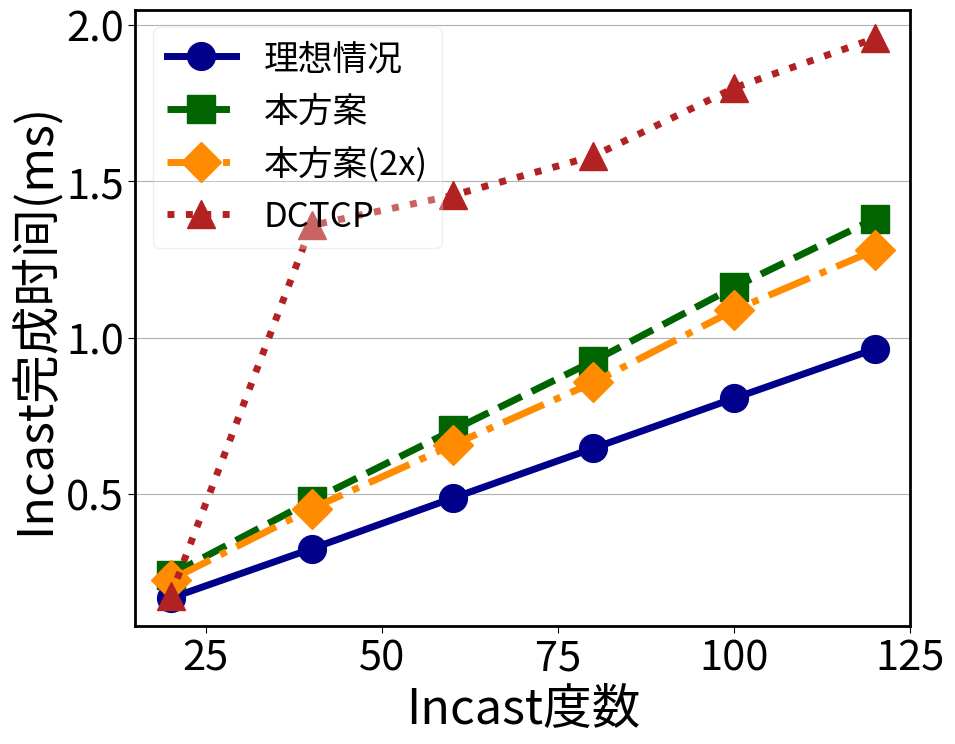

In [13]:
WIDTH = 0.05
def incast_finish_time():
    results = {}
    for i, scheme in enumerate(SCHEMES):
        results[scheme] = []
        for workload in workloads:
            incast_fct = data[scheme][workload]['FCT'][:, 7] # fct
            print(len(incast_fct))
            incast_finish_time = max(incast_fct)
            results[scheme].append(incast_finish_time*1e3)
    



    fig, ax = plt.subplots(figsize=my_figsize)
    # plt.subplots_adjust(left=0.10, right=0.96, bottom=0.15, top=0.9)
    ax.spines['bottom'].set_linewidth(2.0)
    ax.spines['top'].set_linewidth(2.0)
    ax.spines['left'].set_linewidth(2.0)
    ax.spines['right'].set_linewidth(2.0)
    

    for i, scheme in enumerate(SCHEMES):
        ax.plot(incast_degree, results[SCHEMES[i]], color = colors[i], marker = markers[i], markersize=20, linestyle = linestyles[i], linewidth=5, label = SCHEMES_labels[i])
        # ax.plot(incast_degree, results[SCHEMES[i]], color = 'firebrick', marker = 'o', markersize=20, linestyle = 'solid', linewidth=5, label = SCHEMES_labels[i])
    print(results)
    # ax.set_title('Accelerate by adding line rate', fontsize=my_fontsize)
    # ax.set_ylabel('Goodput\n(normalized)', fontsize=my_fontsize)
    ax.set_ylabel('Incast完成时间(ms)', fontsize=my_fontsize)
    # ax.set_xticks(x_tick)
    # ax.set_xlabel("Incast Degree", fontsize=my_fontsize)
    ax.set_xlabel("Incast度数", fontsize=my_fontsize)
    # ax.set_xticklabels(labels, fontsize=my_fontsize)
    ax.legend(ncol=1, loc = "upper left", fontsize=my_fontsize-10, framealpha=0.3)
    ax.tick_params(axis='both', which='both', length=5, labelsize=my_fontsize)
    # ax.legend(ncol=1, loc = "upper left", fontsize=my_fontsize-5, handlelength = 1.5, borderpad = 0.2,  labelspacing = 0.3, columnspacing = 1.0)

    

    plt.xticks(fontsize=my_fontsize-5)
    ax.tick_params(axis='both', which='both', length=5)
    # plt.ylim((0, 250))
    # plt.yticks(np.arange(-1,1.01,0.2), [1.0, 0.8, 0.6, 0.4, 0.2, 0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    # plt.yticks(np.arange(0,1.01,0.2))
    ax.grid(axis="y")
    # plt.yticks([0.2, 0.4, 0.6, 0.8, 1], fontsize=my_fontsize-5)
    plt.yticks(fontsize=my_fontsize-5)
    fig_dir = '../FIGS/Thesis/incast/'
    if not os.path.exists(fig_dir):
        os.makedirs(fig_dir)
    plt.savefig(fig_dir + 'incast_finish_time.pdf', bbox_inches='tight')
# colors = ['darkblue', 'firebrick', 'forestgreen', 'darkorange', 'darkviolet', 'darkturquoise']
colors = ['darkblue', 'darkgreen', 'darkorange', 'firebrick', 'darkviolet', 'darkred', 'darkblue', 'darkgreen', 'darkorange', 'darkviolet', 'darkred']
markers = ['o', 's', 'D', '^', 'v', 'p']
linestyles = ['-', '--', '-.', ':', '-', '--']    
incast_finish_time()